<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Temperature_Celsius/XAI_Temperature_Celcius_3_Iterations_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load your preprocessed dataset
df = pd.read_csv("/content/drive/MyDrive/Research v2/Research 18.03.2026/cleaned_weather_data (1).csv")

# Quick check
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Shape: (130003, 43)
Columns: ['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination', 'condition_text_before', 'wind_direction_before']


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,condition_text_before,wind_direction_before
0,United States of America,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,2024-05-16 01:45:00,16.1,61.0,2,...,1,1,05:26 AM,08:31 PM,01:36 PM,02:52 AM,Waxing Gibbous,55,Clear,SW
1,Honduras,Tegucigalpa,14.10,-87.22,America/Tegucigalpa,1715849100,2024-05-16 02:45:00,23.0,73.4,32,...,2,2,05:22 AM,06:09 PM,12:52 PM,12:55 AM,Waxing Gibbous,55,Partly cloudy,WSW
2,El Salvador,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,2024-05-16 02:45:00,26.0,78.8,23,...,2,2,05:30 AM,06:16 PM,01:00 PM,01:02 AM,Waxing Gibbous,55,Moderate or heavy rain with thunder,S
3,Guatemala,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,2024-05-16 02:45:00,20.0,68.0,19,...,4,10,05:34 AM,06:23 PM,01:05 PM,01:09 AM,Waxing Gibbous,55,Mist,S
4,Belize,Belmopan,17.25,-88.77,America/Belize,1715849100,2024-05-16 02:45:00,26.0,78.9,30,...,1,1,05:23 AM,06:20 PM,12:56 PM,01:04 AM,Waxing Gibbous,55,Overcast,E


In [2]:
target = "temperature_celsius"

if target not in df.columns:
    raise ValueError(f"{target} not found in dataset!")

In [3]:
df.columns = df.columns.str.strip()

In [4]:

import pandas as pd

# -----------------------------
# TARGET
# -----------------------------
target = "temperature_celsius"

# -----------------------------
# 1. REMOVE UNSUITABLE FEATURES
# -----------------------------
# Reasons:
# - highly correlated with target (>85%) -> possible leakage
# - duplicate units
# - weak usefulness / near-zero correlation
# - timestamp less interpretable unless converted to datetime features

remove_features = [
    "temperature_fahrenheit",      # 100.0 correlation with temperature_celsius
    "feels_like_celsius",          # 98.4 correlation with temperature_celsius
    "feels_like_fahrenheit",       # 98.4 correlation with temperature_celsius
    "wind_kph",                    # duplicate of wind_mph
    "pressure_in",                 # duplicate of pressure_mb
    "precip_in",                   # duplicate of precip_mm
    "visibility_miles",            # duplicate of visibility_km
    "gust_kph",                    # duplicate of gust_mph
    "moon_illumination",           # almost no correlation
    "air_quality_Carbon_Monoxide", # almost no correlation
    "last_updated_epoch"           # use only if converted into useful datetime features
]

# drop only if they exist
existing_remove_features = [col for col in remove_features if col in df.columns]

print("Features removed:")
print(existing_remove_features)

df_clean = df.drop(columns=existing_remove_features, errors="ignore")

# -----------------------------
# 2. SELECT MOST SUITABLE 15 FEATURES
# -----------------------------
# Chosen based on:
# - reasonable correlation with target
# - no severe target leakage
# - no duplicate-unit columns
selected_features = [
    "uv_index",
    "latitude",
    "humidity",
    "pressure_mb",
    "air_quality_Ozone",
    "condition_text",
    "air_quality_Nitrogen_dioxide",
    "cloud",
    "visibility_km",
    "longitude",
    "air_quality_PM10",
    "wind_mph",
    "gust_mph",
    "wind_degree",
    "precip_mm"
]

# keep only features that actually exist
selected_features = [col for col in selected_features if col in df_clean.columns]

print("\nSelected suitable features for temperature_celsius:")
print(selected_features)

# -----------------------------
# 3. FINAL DATASET FOR temperature_celsius
# -----------------------------
X_temp = df_clean[selected_features]
y_temp = df_clean[target]

final_temp_df = pd.concat([X_temp, y_temp], axis=1)

print("\nFinal dataset shape:")
print(final_temp_df.shape)

print("\nFinal dataset columns:")
print(final_temp_df.columns.tolist())

# preview
final_temp_df.head()

Features removed:
['temperature_fahrenheit', 'feels_like_celsius', 'feels_like_fahrenheit', 'wind_kph', 'pressure_in', 'precip_in', 'visibility_miles', 'gust_kph', 'moon_illumination', 'air_quality_Carbon_Monoxide', 'last_updated_epoch']

Selected suitable features for temperature_celsius:
['uv_index', 'latitude', 'humidity', 'pressure_mb', 'air_quality_Ozone', 'condition_text', 'air_quality_Nitrogen_dioxide', 'cloud', 'visibility_km', 'longitude', 'air_quality_PM10', 'wind_mph', 'gust_mph', 'wind_degree', 'precip_mm']

Final dataset shape:
(130003, 16)

Final dataset columns:
['uv_index', 'latitude', 'humidity', 'pressure_mb', 'air_quality_Ozone', 'condition_text', 'air_quality_Nitrogen_dioxide', 'cloud', 'visibility_km', 'longitude', 'air_quality_PM10', 'wind_mph', 'gust_mph', 'wind_degree', 'precip_mm', 'temperature_celsius']


,uv_index,latitude,humidity,pressure_mb,air_quality_Ozone,condition_text,air_quality_Nitrogen_dioxide,cloud,visibility_km,longitude,air_quality_PM10,wind_mph,gust_mph,wind_degree,precip_mm,temperature_celsius
0,1.0,46.60,58,1012.0,62.2,2,2.5,0,16.0,-120.49,7.1,4.3,10.3,220,0.00,16.1
1,1.0,14.10,78,1017.0,23.3,32,3.7,37,10.0,-87.22,25.3,3.8,7.0,240,0.28,23.0
2,1.0,13.71,94,1010.0,5.9,23,7.7,50,10.0,-89.20,28.1,2.2,2.8,182,0.30,26.0
3,1.0,14.62,88,1019.0,0.4,19,35.0,100,5.0,-90.53,178.1,13.6,18.1,190,0.09,20.0
4,1.0,17.25,89,1007.0,34.0,30,0.3,94,10.0,-88.77,32.1,4.3,6.5,99,0.00,26.0


In [5]:

removed_table = pd.DataFrame({
    "Removed Features": existing_remove_features
})

selected_table = pd.DataFrame({
    "Selected Features for temperature_celsius": selected_features
})

print("Removed Features Table")
display(removed_table)

print("Selected Features Table")
display(selected_table)

Removed Features Table


,Removed Features
0,temperature_fahrenheit
1,feels_like_celsius
2,feels_like_fahrenheit
3,wind_kph
4,pressure_in
5,precip_in
6,visibility_miles
7,gust_kph
8,moon_illumination
9,air_quality_Carbon_Monoxide


Selected Features Table


,Selected Features for temperature_celsius
0,uv_index
1,latitude
2,humidity
3,pressure_mb
4,air_quality_Ozone
5,condition_text
6,air_quality_Nitrogen_dioxide
7,cloud
8,visibility_km
9,longitude


In [6]:

from google.colab import files

# Save file in Colab
final_temp_df.to_csv("final_temperature_dataset.csv", index=False)

# Download to your computer
files.download("final_temperature_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:

import pandas as pd
import numpy as np

# -----------------------------
# TARGET AND SELECTED FEATURES
# -----------------------------
target = "temperature_celsius"

selected_features = [
    "uv_index",
    "latitude",
    "humidity",
    "pressure_mb",
    "air_quality_Ozone",
    "condition_text",
    "air_quality_Nitrogen_dioxide",
    "cloud",
    "visibility_km",
    "longitude",
    "air_quality_PM10",
    "wind_mph",
    "gust_mph",
    "wind_degree",
    "precip_mm"
]

# -----------------------------
# BUILD DATASET
# -----------------------------
temp_df = df[["last_updated"] + selected_features + [target]].copy()

temp_df["last_updated"] = pd.to_datetime(temp_df["last_updated"], errors="coerce")
temp_df = temp_df.dropna(subset=["last_updated"])
temp_df = temp_df.sort_values("last_updated").reset_index(drop=True)

# Drop any remaining missing rows
temp_df = temp_df.dropna().reset_index(drop=True)

print("Temperature dataset shape:", temp_df.shape)
temp_df.head()

Temperature dataset shape: (130003, 17)


,last_updated,uv_index,latitude,humidity,pressure_mb,air_quality_Ozone,condition_text,air_quality_Nitrogen_dioxide,cloud,visibility_km,longitude,air_quality_PM10,wind_mph,gust_mph,wind_degree,precip_mm,temperature_celsius
0,2024-05-16 01:45:00,1.0,46.60,58,1012.0,62.2,2,2.5,0,16.0,-120.49,7.1,4.3,10.3,220,0.00,16.1
1,2024-05-16 02:45:00,1.0,14.10,78,1017.0,23.3,32,3.7,37,10.0,-87.22,25.3,3.8,7.0,240,0.28,23.0
2,2024-05-16 02:45:00,1.0,13.71,94,1010.0,5.9,23,7.7,50,10.0,-89.20,28.1,2.2,2.8,182,0.30,26.0
3,2024-05-16 02:45:00,1.0,14.62,88,1019.0,0.4,19,35.0,100,5.0,-90.53,178.1,13.6,18.1,190,0.09,20.0
4,2024-05-16 02:45:00,1.0,17.25,89,1007.0,34.0,30,0.3,94,10.0,-88.77,32.1,4.3,6.5,99,0.00,26.0


In [8]:

import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load your cleaned final temperature dataset
path = "/content/drive/MyDrive/Research v2/Research 18.03.2026/Temperature_Celsius/final_temperature_dataset.csv"
temp_df = pd.read_csv(path)

print("Dataset shape:", temp_df.shape)
temp_df.head()


Dataset shape: (130003, 16)


,uv_index,latitude,humidity,pressure_mb,air_quality_Ozone,condition_text,air_quality_Nitrogen_dioxide,cloud,visibility_km,longitude,air_quality_PM10,wind_mph,gust_mph,wind_degree,precip_mm,temperature_celsius
0,1.0,46.60,58,1012.0,62.2,2,2.5,0,16.0,-120.49,7.1,4.3,10.3,220,0.00,16.1
1,1.0,14.10,78,1017.0,23.3,32,3.7,37,10.0,-87.22,25.3,3.8,7.0,240,0.28,23.0
2,1.0,13.71,94,1010.0,5.9,23,7.7,50,10.0,-89.20,28.1,2.2,2.8,182,0.30,26.0
3,1.0,14.62,88,1019.0,0.4,19,35.0,100,5.0,-90.53,178.1,13.6,18.1,190,0.09,20.0
4,1.0,17.25,89,1007.0,34.0,30,0.3,94,10.0,-88.77,32.1,4.3,6.5,99,0.00,26.0


In [9]:
target = "temperature_celsius"

selected_features = [col for col in temp_df.columns if col != target]

print("Target:", target)
print("Number of features:", len(selected_features))
print(selected_features)

Target: temperature_celsius
Number of features: 15
['uv_index', 'latitude', 'humidity', 'pressure_mb', 'air_quality_Ozone', 'condition_text', 'air_quality_Nitrogen_dioxide', 'cloud', 'visibility_km', 'longitude', 'air_quality_PM10', 'wind_mph', 'gust_mph', 'wind_degree', 'precip_mm']


In [10]:

# -----------------------------
# 80% TRAIN / 20% TEST
# -----------------------------
split_index = int(0.8 * len(temp_df))

train_df = temp_df.iloc[:split_index].copy()
test_df = temp_df.iloc[split_index:].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (104002, 16)
Test shape : (26001, 16)


In [11]:
from google.colab import files

# Save training dataset
train_df.to_csv("temp_training_dataset.csv", index=False)

# Save testing dataset
test_df.to_csv("temp_testing_dataset.csv", index=False)

# Download both files
files.download("temp_training_dataset.csv")
files.download("temp_testing_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:

# -----------------------------
# ITERATION 1, 2, 3 FROM TRAINING DATA
# -----------------------------
n_train = len(train_df)

iter1 = train_df.iloc[:int(0.33 * n_train)].copy()
iter2 = train_df.iloc[int(0.33 * n_train):int(0.66 * n_train)].copy()
iter3 = train_df.iloc[int(0.66 * n_train):].copy()

print("Iteration 1 shape:", iter1.shape)
print("Iteration 2 shape:", iter2.shape)
print("Iteration 3 shape:", iter3.shape)

Iteration 1 shape: (34320, 16)
Iteration 2 shape: (34321, 16)
Iteration 3 shape: (35361, 16)


In [13]:
def get_xy(data):
    X = data[selected_features]
    y = data[target]
    return X, y

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    accuracy = r2 * 100
    return mse, rmse, mae, r2, accuracy

In [14]:

X1, y1 = get_xy(iter1)
X2, y2 = get_xy(iter2)
X3, y3 = get_xy(iter3)

X_test, y_test = get_xy(test_df)

print(X1.shape, X2.shape, X3.shape, X_test.shape)

(34320, 15) (34321, 15) (35361, 15) (26001, 15)


In [15]:
results = []            # for iteration-wise RMSE comparison table
all_iteration_metrics = []  # for full training iteration metrics of each model
final_test_results = [] # for final unseen test results

In [16]:

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Iteration 1
rf_model.fit(X1, y1)
rf_pred1 = rf_model.predict(X1)
mse, rmse, mae, r2, acc = calculate_metrics(y1, rf_pred1)
results.append(["Iteration 1", "Random Forest", rmse])
all_iteration_metrics.append(["Iteration 1", "Random Forest", mse, rmse, mae, r2, acc])

# Iteration 2
X12 = pd.concat([X1, X2])
y12 = pd.concat([y1, y2])
rf_model.fit(X12, y12)
rf_pred2 = rf_model.predict(X2)
mse, rmse, mae, r2, acc = calculate_metrics(y2, rf_pred2)
results.append(["Iteration 2", "Random Forest", rmse])
all_iteration_metrics.append(["Iteration 2", "Random Forest", mse, rmse, mae, r2, acc])

# Iteration 3
X123 = pd.concat([X1, X2, X3])
y123 = pd.concat([y1, y2, y3])
rf_model.fit(X123, y123)
rf_pred3 = rf_model.predict(X3)
mse, rmse, mae, r2, acc = calculate_metrics(y3, rf_pred3)
results.append(["Iteration 3", "Random Forest", rmse])
all_iteration_metrics.append(["Iteration 3", "Random Forest", mse, rmse, mae, r2, acc])

# Final test
rf_test_pred = rf_model.predict(X_test)
mse, rmse, mae, r2, acc = calculate_metrics(y_test, rf_test_pred)
final_test_results.append(["Random Forest", mse, rmse, mae, r2, acc])

In [17]:
all_iteration_metrics_df = pd.DataFrame(
    all_iteration_metrics,
    columns=["Iteration", "Model", "MSE", "RMSE", "MAE", "R2", "Accuracy (%)"]
).round(3)

all_iteration_metrics_df

,Iteration,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,Iteration 1,Random Forest,0.390,0.625,0.427,0.993,99.291
1,Iteration 2,Random Forest,0.831,0.911,0.608,0.992,99.212
2,Iteration 3,Random Forest,0.878,0.937,0.614,0.984,98.385


In [18]:

results_df = pd.DataFrame(results, columns=["Iteration", "Model", "RMSE"])

comparison_table = results_df.pivot(
    index="Iteration",
    columns="Model",
    values="RMSE"
)

comparison_table = comparison_table.reindex(["Iteration 1", "Iteration 2", "Iteration 3"]).round(3)

comparison_table

Model,Random Forest
Iteration,
Iteration 1,0.625
Iteration 2,0.911
Iteration 3,0.937


In [19]:

final_test_df = pd.DataFrame(
    final_test_results,
    columns=["Model", "MSE", "RMSE", "MAE", "R2", "Accuracy (%)"]
).round(3)

final_test_df

,Model,MSE,RMSE,MAE,R2,Accuracy (%)
0,Random Forest,27.419,5.236,3.504,0.779,77.923


In [20]:
rf_model
X_test
y_test
rf_test_pred

array([21.568,  7.548,  6.046, ...,  9.198, 26.499, 22.553])

In [21]:
# ============================================================
# TEMPERATURE RANDOM FOREST - SHAP EXPLAINABLE AI
# Save and download all charts and tables
# ============================================================

import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from google.colab import files
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

shap.initjs()

save_dir = "/content/Temperature_RF_SHAP_Outputs"
os.makedirs(save_dir, exist_ok=True)

def safe_name(name):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(name))

print("Random Forest model:", rf_model)
print("X_test shape:", X_test.shape)
print("y_test length:", len(y_test))

Random Forest model: RandomForestRegressor(n_jobs=-1, random_state=42)
X_test shape: (26001, 15)
y_test length: 26001


In [22]:
# ============================================================
# 2. RANDOM FOREST PREDICTIONS AND METRICS
# ============================================================

try:
    temperature_pred = np.asarray(rf_test_pred)
    print("Using existing rf_test_pred")
except NameError:
    temperature_pred = rf_model.predict(X_test)
    print("Generated predictions using rf_model")

y_test_array = np.asarray(y_test).reshape(-1)
temperature_pred = np.asarray(temperature_pred).reshape(-1)

if len(y_test_array) != len(temperature_pred):
    raise ValueError(
        f"Length mismatch: y_test has {len(y_test_array)} values, "
        f"but predictions have {len(temperature_pred)} values."
    )

mse = mean_squared_error(y_test_array, temperature_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_array, temperature_pred)
r2 = r2_score(y_test_array, temperature_pred)

metrics_df = pd.DataFrame({
    "Target": ["temperature_celsius"],
    "Model": ["Random Forest"],
    "MSE": [mse],
    "RMSE": [rmse],
    "MAE": [mae],
    "R2": [r2],
    "R2_Percentage": [r2 * 100]
})

metrics_df.to_csv(
    f"{save_dir}/Temperature_RF_Metrics.csv",
    index=False
)

print("Random Forest performance")
display(metrics_df)

Using existing rf_test_pred
Random Forest performance


,Target,Model,MSE,RMSE,MAE,R2,R2_Percentage
0,temperature_celsius,Random Forest,27.418827,5.236299,3.503756,0.779232,77.92323


In [23]:
# ============================================================
# 3. PREPARE SHAP SAMPLE
# ============================================================

# 500 samples usually provide a good balance of speed and explanation
shap_sample_size = min(500, len(X_test))

X_sample = X_test.sample(
    n=shap_sample_size,
    random_state=42
).copy()

print("SHAP sample size:", X_sample.shape)

# TreeExplainer is optimized for Random Forest
explainer = shap.TreeExplainer(rf_model)

# Calculate regular SHAP values
shap_values = explainer.shap_values(X_sample)

# Handle possible list output
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

print("SHAP values shape:", shap_values.shape)

if shap_values.shape != X_sample.shape:
    raise ValueError(
        f"Unexpected SHAP shape {shap_values.shape}; "
        f"expected {X_sample.shape}."
    )

SHAP sample size: (500, 15)
SHAP values shape: (500, 15)


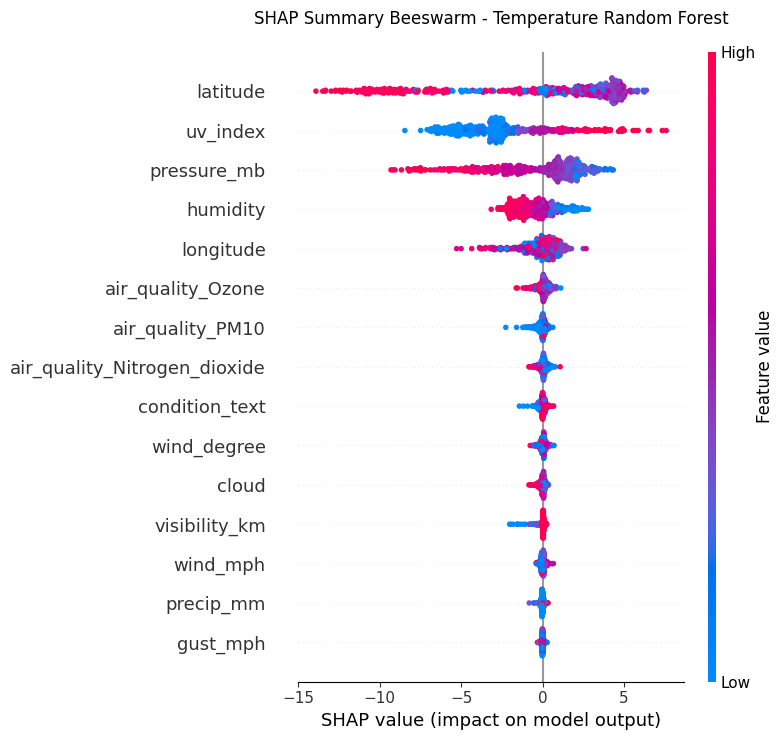

In [24]:
# ============================================================
# 4. SHAP SUMMARY BEESWARM
# ============================================================

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X_sample.columns,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Beeswarm - Temperature Random Forest",
    pad=20
)

plt.tight_layout()

plt.savefig(
    f"{save_dir}/01_SHAP_Summary_Beeswarm_Temperature_RF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

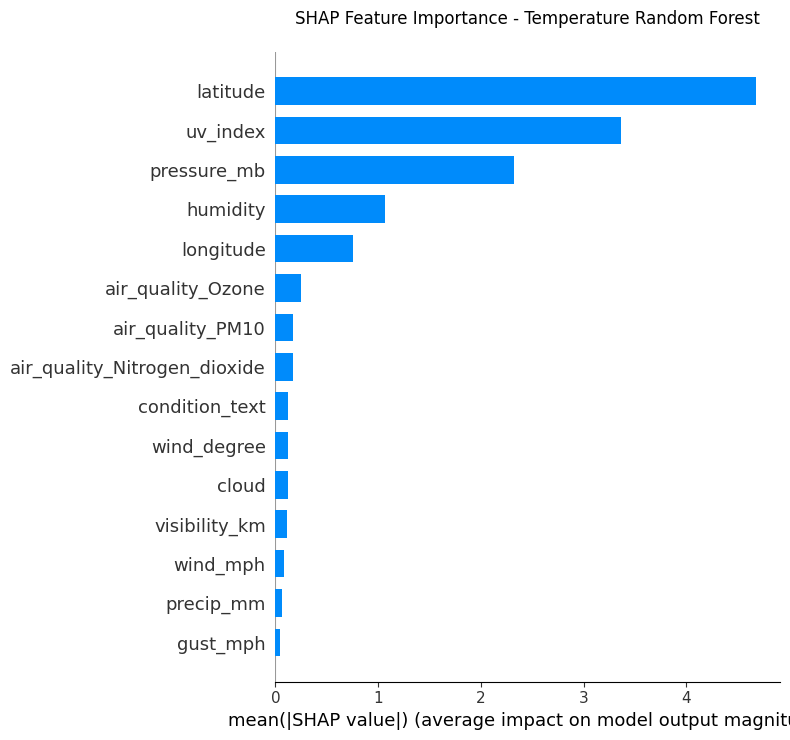

In [25]:
# ============================================================
# 5. SHAP FEATURE IMPORTANCE BAR PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X_sample.columns,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "SHAP Feature Importance - Temperature Random Forest",
    pad=20
)

plt.tight_layout()

plt.savefig(
    f"{save_dir}/02_SHAP_Bar_Temperature_RF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [26]:
# ============================================================
# 6. SHAP FEATURE IMPORTANCE TABLE
# ============================================================

mean_absolute_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_sample.columns,
    "Mean_Absolute_SHAP": mean_absolute_shap
}).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

shap_importance_df.to_csv(
    f"{save_dir}/Temperature_RF_SHAP_Feature_Importance.csv",
    index=False
)

print("SHAP feature importance")
display(shap_importance_df)

SHAP feature importance


,Feature,Mean_Absolute_SHAP
0,latitude,4.677986
1,uv_index,3.367983
2,pressure_mb,2.318391
3,humidity,1.065992
4,longitude,0.756879
5,air_quality_Ozone,0.246681
6,air_quality_PM10,0.172588
7,air_quality_Nitrogen_dioxide,0.167401
8,condition_text,0.126418
9,wind_degree,0.125849


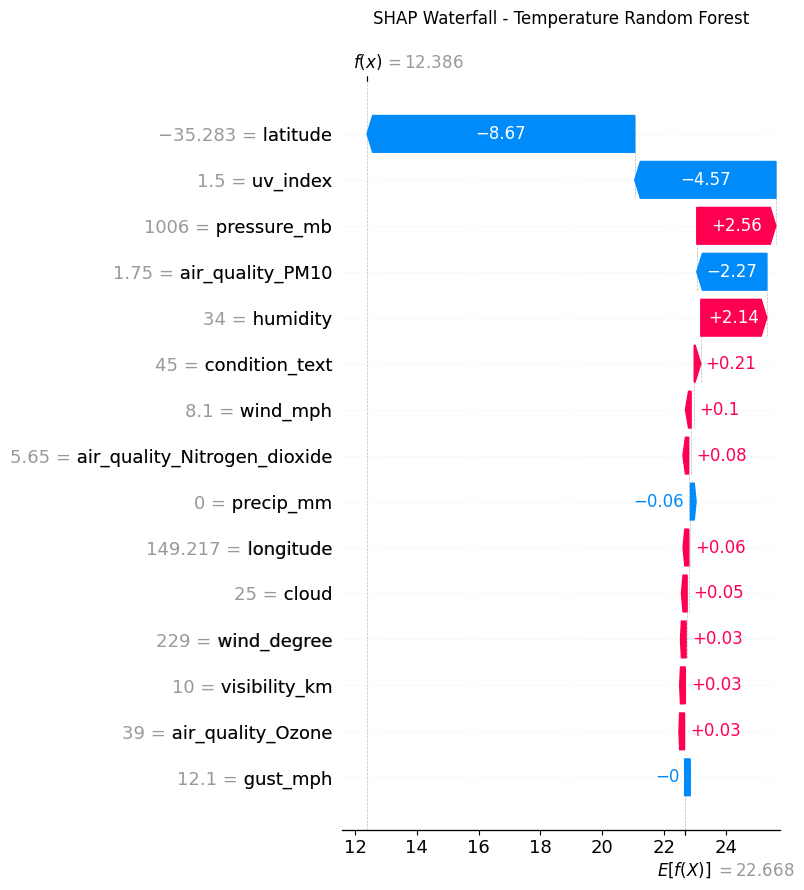

In [27]:
# ============================================================
# 7. SHAP WATERFALL PLOT
# ============================================================

sample_index = 0

base_value = explainer.expected_value

if isinstance(base_value, (list, np.ndarray)):
    base_value = np.asarray(base_value).reshape(-1)[0]

waterfall_explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=base_value,
    data=X_sample.iloc[sample_index].values,
    feature_names=X_sample.columns.tolist()
)

shap.plots.waterfall(
    waterfall_explanation,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Waterfall - Temperature Random Forest",
    pad=20
)

plt.tight_layout()

plt.savefig(
    f"{save_dir}/03_SHAP_Waterfall_Temperature_RF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [28]:
# ============================================================
# 8. IDENTIFY TOP THREE SHAP FEATURES
# ============================================================

top3_features = (
    shap_importance_df["Feature"]
    .head(3)
    .tolist()
)

print("Top three SHAP features:")

for position, feature in enumerate(top3_features, start=1):
    print(f"{position}. {feature}")

Top three SHAP features:
1. latitude
2. uv_index
3. pressure_mb


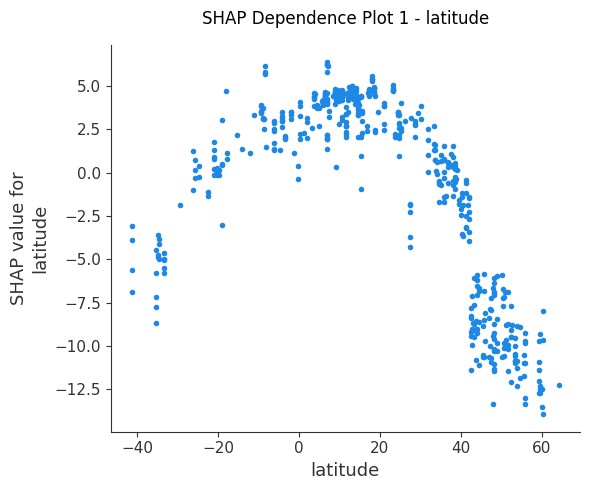

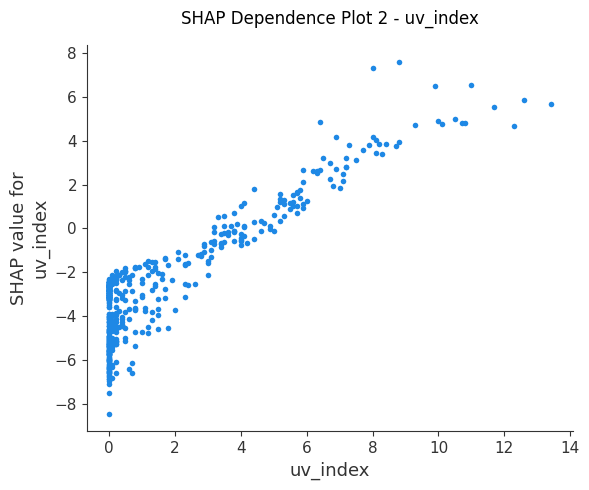

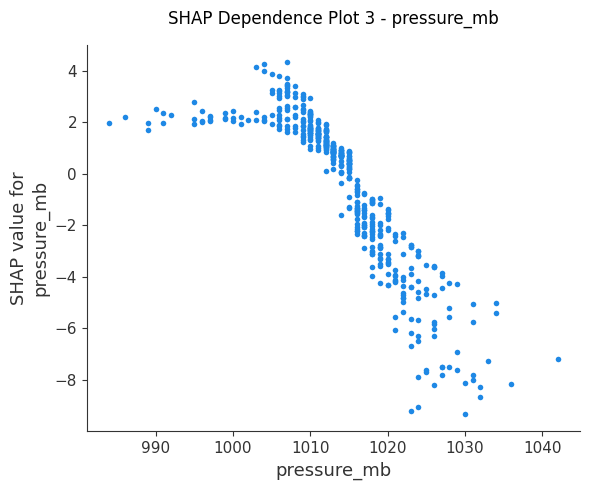

In [29]:
# ============================================================
# 9. SHAP DEPENDENCE PLOTS - TOP THREE FEATURES
# ============================================================

for position, feature in enumerate(top3_features, start=1):

    shap.dependence_plot(
        feature,
        shap_values,
        X_sample,
        interaction_index=None,
        show=False
    )

    plt.title(
        f"SHAP Dependence Plot {position} - {feature}",
        pad=15
    )

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/04_{position}_SHAP_Dependence_"
        f"{safe_name(feature)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

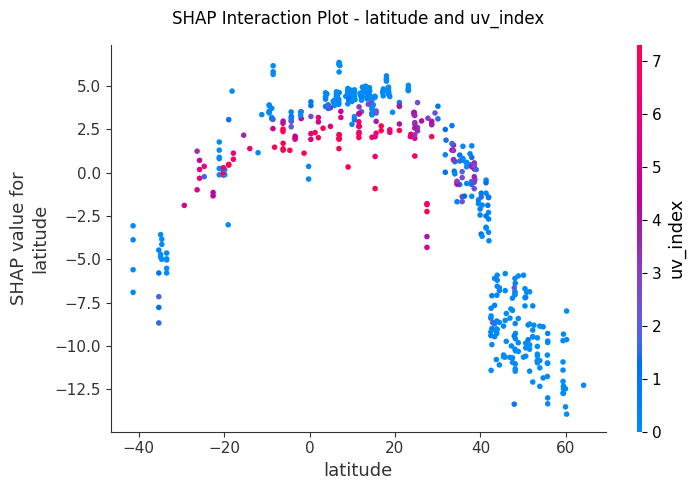

In [30]:
# ============================================================
# 10. FAST SHAP INTERACTION PLOT
# ============================================================

feature1 = top3_features[0]
feature2 = top3_features[1]

shap.dependence_plot(
    feature1,
    shap_values,
    X_sample,
    interaction_index=feature2,
    show=False
)

plt.title(
    f"SHAP Interaction Plot - {feature1} and {feature2}",
    pad=15
)

plt.tight_layout()

plt.savefig(
    f"{save_dir}/05_SHAP_Interaction_"
    f"{safe_name(feature1)}_"
    f"{safe_name(feature2)}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

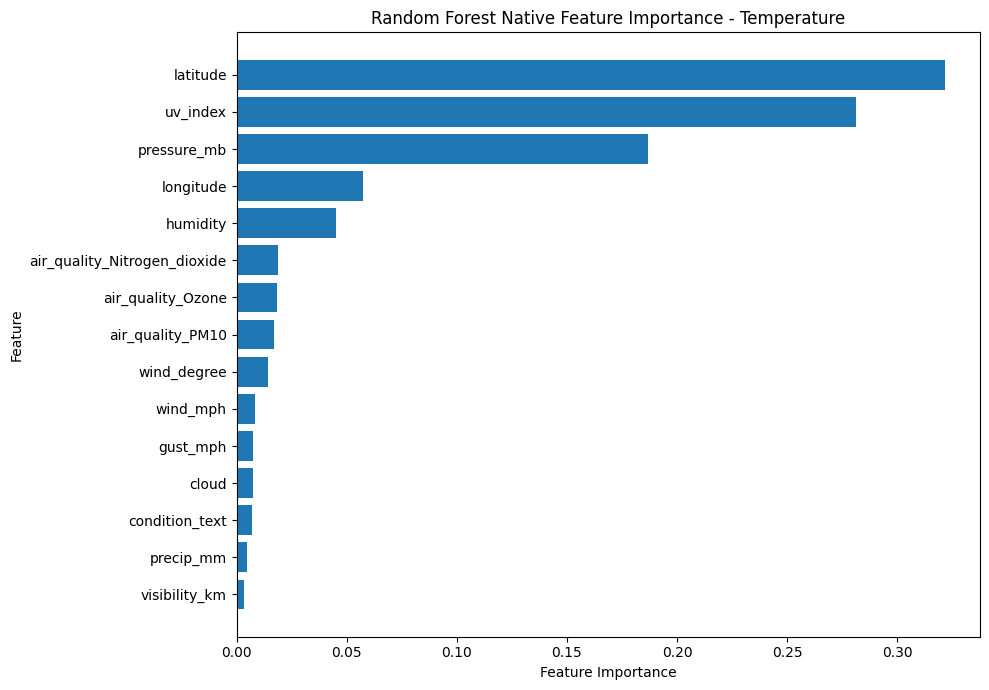

,Feature,Random_Forest_Importance
0,latitude,0.321437
1,uv_index,0.281311
2,pressure_mb,0.186907
3,longitude,0.057599
4,humidity,0.045146
5,air_quality_Nitrogen_dioxide,0.019009
6,air_quality_Ozone,0.018522
7,air_quality_PM10,0.016971
8,wind_degree,0.014347
9,wind_mph,0.008391


In [31]:
# ============================================================
# 11. RANDOM FOREST NATIVE FEATURE IMPORTANCE
# ============================================================

rf_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Random_Forest_Importance": rf_model.feature_importances_
}).sort_values(
    by="Random_Forest_Importance",
    ascending=False
).reset_index(drop=True)

rf_importance_df.to_csv(
    f"{save_dir}/Temperature_RF_Native_Feature_Importance.csv",
    index=False
)

top_rf_features = rf_importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf_features["Feature"][::-1],
    top_rf_features["Random_Forest_Importance"][::-1]
)

plt.title(
    "Random Forest Native Feature Importance - Temperature"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    f"{save_dir}/06_RF_Native_Feature_Importance_Temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

display(rf_importance_df)

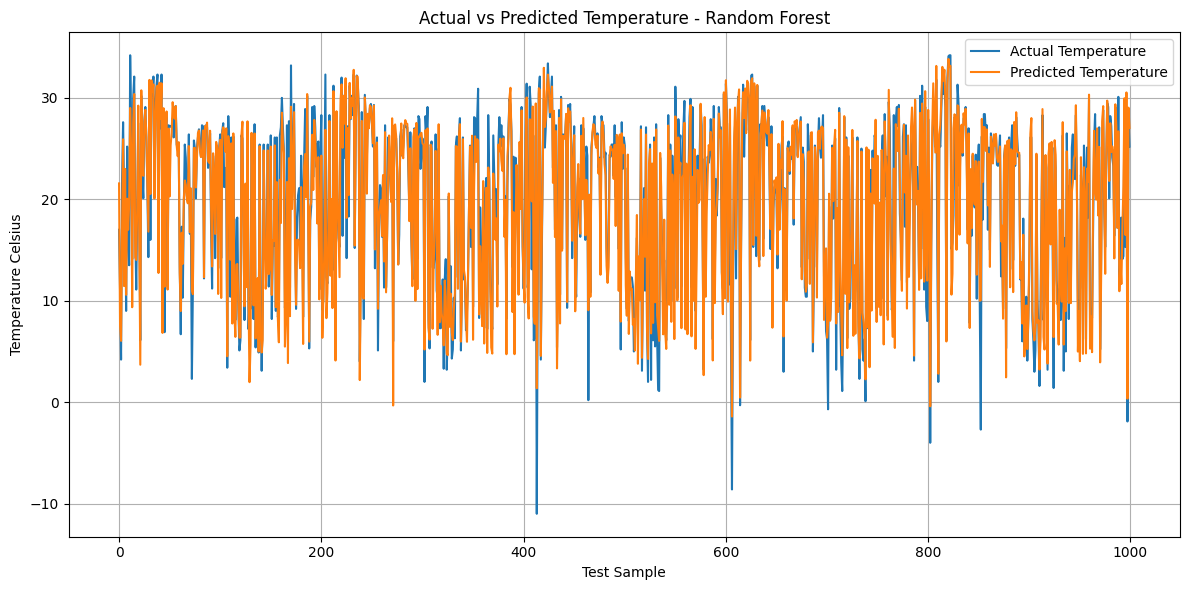

In [32]:
# ============================================================
# 12. ACTUAL VS PREDICTED TEMPERATURE
# ============================================================

plot_count = min(1000, len(y_test_array))

plt.figure(figsize=(12, 6))

plt.plot(
    y_test_array[:plot_count],
    label="Actual Temperature"
)

plt.plot(
    temperature_pred[:plot_count],
    label="Predicted Temperature"
)

plt.title(
    "Actual vs Predicted Temperature - Random Forest"
)

plt.xlabel("Test Sample")
plt.ylabel("Temperature Celsius")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/07_Actual_vs_Predicted_Temperature_RF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

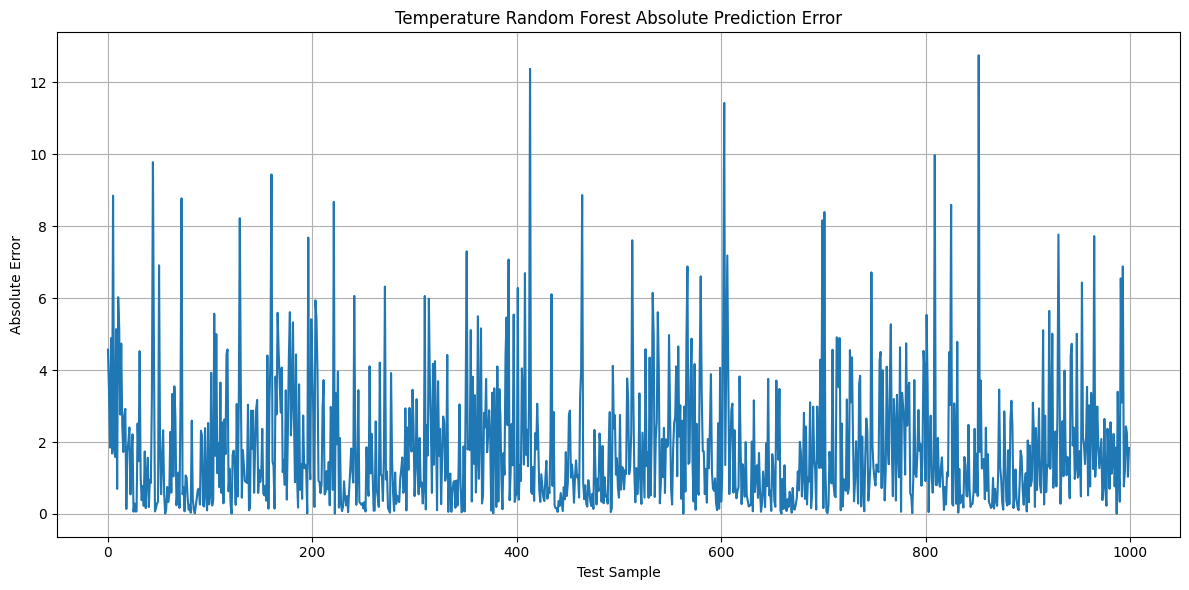

In [33]:
# ============================================================
# 13. ABSOLUTE PREDICTION ERROR
# ============================================================

absolute_error = np.abs(
    y_test_array - temperature_pred
)

plt.figure(figsize=(12, 6))

plt.plot(
    absolute_error[:plot_count]
)

plt.title(
    "Temperature Random Forest Absolute Prediction Error"
)

plt.xlabel("Test Sample")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/08_Prediction_Error_Temperature_RF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

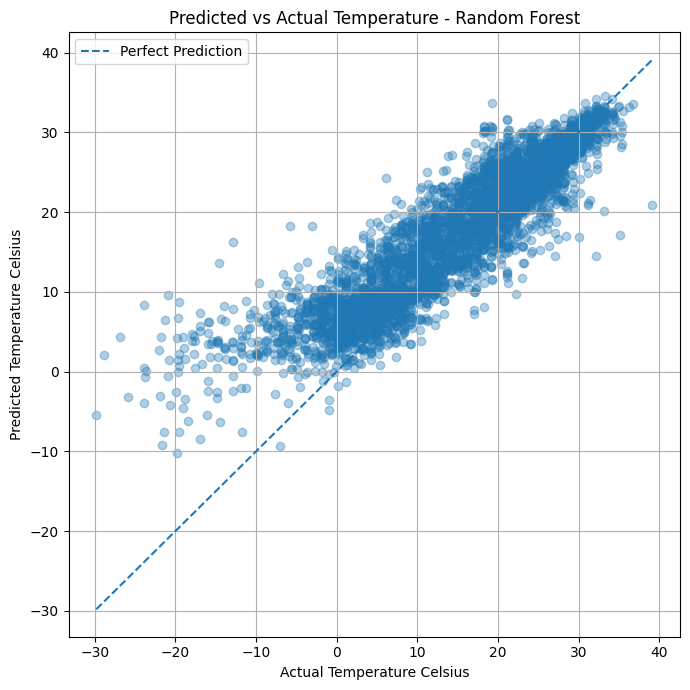

In [34]:
# ============================================================
# 14. PREDICTED VS ACTUAL SCATTER PLOT
# ============================================================

# Sampling the scatter plot reduces rendering time
scatter_sample_size = min(5000, len(y_test_array))

rng = np.random.default_rng(42)

scatter_indices = rng.choice(
    len(y_test_array),
    size=scatter_sample_size,
    replace=False
)

scatter_actual = y_test_array[scatter_indices]
scatter_predicted = temperature_pred[scatter_indices]

minimum_value = min(
    scatter_actual.min(),
    scatter_predicted.min()
)

maximum_value = max(
    scatter_actual.max(),
    scatter_predicted.max()
)

plt.figure(figsize=(7, 7))

plt.scatter(
    scatter_actual,
    scatter_predicted,
    alpha=0.35
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.title(
    "Predicted vs Actual Temperature - Random Forest"
)

plt.xlabel("Actual Temperature Celsius")
plt.ylabel("Predicted Temperature Celsius")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/09_Predicted_vs_Actual_Scatter_Temperature_RF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

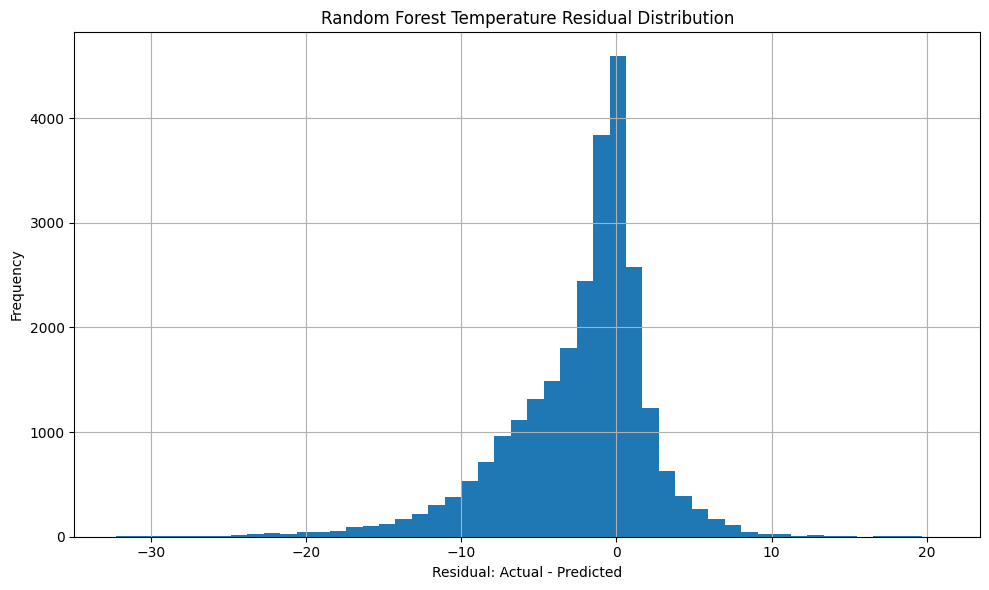

In [35]:
# ============================================================
# 15. RESIDUAL DISTRIBUTION
# ============================================================

residuals = y_test_array - temperature_pred

plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=50
)

plt.title(
    "Random Forest Temperature Residual Distribution"
)

plt.xlabel("Residual: Actual - Predicted")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{save_dir}/10_Residual_Distribution_Temperature_RF.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [36]:
# ============================================================
# 16. SAVE INDIVIDUAL SHAP VALUES
# ============================================================

shap_values_df = pd.DataFrame(
    shap_values,
    columns=X_sample.columns
)

shap_values_df.insert(
    0,
    "Original_Row_Index",
    X_sample.index
)

shap_values_df.to_csv(
    f"{save_dir}/Temperature_RF_Individual_SHAP_Values.csv",
    index=False
)

X_sample.to_csv(
    f"{save_dir}/Temperature_RF_SHAP_Input_Sample.csv",
    index=True
)

prediction_results_df = pd.DataFrame({
    "Actual_Temperature": y_test_array,
    "Predicted_Temperature": temperature_pred,
    "Residual": residuals,
    "Absolute_Error": absolute_error
})

prediction_results_df.to_csv(
    f"{save_dir}/Temperature_RF_Prediction_Results.csv",
    index=False
)

print("All CSV outputs saved successfully")

All CSV outputs saved successfully


In [37]:
# ============================================================
# 16. SAVE INDIVIDUAL SHAP VALUES
# ============================================================

shap_values_df = pd.DataFrame(
    shap_values,
    columns=X_sample.columns
)

shap_values_df.insert(
    0,
    "Original_Row_Index",
    X_sample.index
)

shap_values_df.to_csv(
    f"{save_dir}/Temperature_RF_Individual_SHAP_Values.csv",
    index=False
)

X_sample.to_csv(
    f"{save_dir}/Temperature_RF_SHAP_Input_Sample.csv",
    index=True
)

prediction_results_df = pd.DataFrame({
    "Actual_Temperature": y_test_array,
    "Predicted_Temperature": temperature_pred,
    "Residual": residuals,
    "Absolute_Error": absolute_error
})

prediction_results_df.to_csv(
    f"{save_dir}/Temperature_RF_Prediction_Results.csv",
    index=False
)

print("All CSV outputs saved successfully")

All CSV outputs saved successfully


In [38]:
# ============================================================
# 17. ZIP AND DOWNLOAD ALL OUTPUTS
# ============================================================

zip_path = "/content/Temperature_RF_SHAP_Optimized_Outputs.zip"

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for root, directories, filenames in os.walk(save_dir):

        for filename in filenames:

            file_path = os.path.join(
                root,
                filename
            )

            zip_file.write(
                file_path,
                arcname=os.path.relpath(
                    file_path,
                    save_dir
                )
            )

print("ZIP file created successfully")
print(zip_path)

files.download(zip_path)

ZIP file created successfully
/content/Temperature_RF_SHAP_Optimized_Outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>